Практическая работа №2
Решение трансцендентных и алгебраических уравнений методом половинного деления

In [2]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt
import math

# Настройка отображения графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

Задание 1. Отделение корней графическим методом


Интервалы отделения корней:
Корень найден в интервале: [-1.47, -1.37]
Корень найден в интервале: [0.57, 0.67]


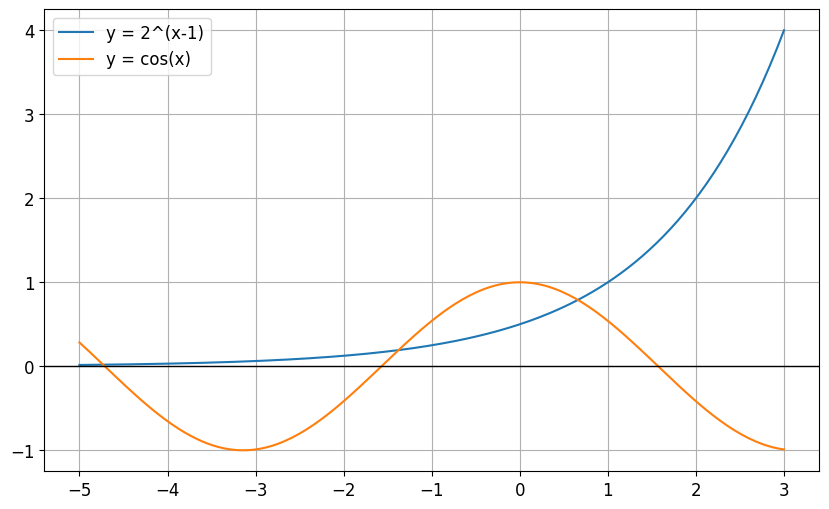

In [6]:
from numpy import *
import pandas as pd

# Исходная функция
def f(x):
    return 2**(x-1) - cos(x)

# Создаем данные для анализа
x_vals = linspace(-3, 2, 50)
y_vals = f(x_vals)

# Таблица для визуального контроля смены знаков
df = pd.DataFrame({'x': x_vals, 'f(x)': y_vals})

# Вывод только тех участков, где функция меняет знак
print("Интервалы отделения корней:")
for i in range(len(df) - 1):
    if df['f(x)'][i] * df['f(x)'][i+1] < 0:
        a = df['x'][i]
        b = df['x'][i+1]
        print(f"Корень найден в интервале: [{a:.2f}, {b:.2f}]")

# Построение графиков для отчета
import matplotlib.pyplot as plt
x_plt = linspace(-5, 3, 200)
plt.plot(x_plt, 2**(x_plt-1), label='y = 2^(x-1)')
plt.plot(x_plt, cos(x_plt), label='y = cos(x)')
plt.axhline(0, color='black', lw=1)
plt.grid(True)
plt.legend()
plt.show()

Задание 2. Уточнение корня методом половинного деления с точностью ε

Метод половинного деления (бисекции):

Делим отрезок [a, b] пополам точкой c = (a+b)/2

Определяем, на каком из полученных отрезков [a, c] или [c, b] функция меняет знак

Продолжаем процесс до достижения требуемой точности: (b-a)/2 < ε

In [4]:
from numpy import *
import pandas as pd

# Исходная функция
def f(x):
    return 2**x - 2 * cos(x)

def bisection_method(a, b, eps):
    # Проверка на наличие корня на отрезке
    if f(a) * f(b) >= 0:
        print(f"Ошибка: знаки функции на концах [{a}, {b}] одинаковы.")
        return None

    # Список для сбора данных (для формирования таблицы Pandas)
    history = []
    
    iteration = 0
    # Основной цикл метода
    while (b - a) / 2 > eps:
        c = (a + b) / 2
        fc = f(c)
        
        # Сохраняем данные шага
        history.append({
            'n': iteration,
            'a': round(a, 6),
            'b': round(b, 6),
            'c': round(c, 6),
            'f(c)': round(fc, 6),
            ' погрешность': round((b - a) / 2, 6)
        })

        # Сдвиг границ
        if f(a) * fc < 0:
            b = c
        else:
            a = c
        iteration += 1

    c_final = (a + b) / 2
    
    # Создание и вывод таблицы без рамок
    df = pd.DataFrame(history)
    print("Ход решения (Метод половинного деления):")
    print(df.to_string(index=False)) # Вывод чистой таблицы
    
    print("-" * 60)
    print(f"Корень x = {c_final:.6f}")
    print(f"f(x) = {f(c_final):.6f}")
    print(f"Итераций: {iteration}")
    
    return c_final

# Входные данные для варианта 4
a_val, b_val = 0.0, 1.0
precision = 0.001

# Запуск
root = bisection_method(a_val, b_val, precision)

Ход решения (Метод половинного деления):
 n       a        b        c      f(c)   погрешность
 0 0.00000 1.000000 0.500000 -0.340952      0.500000
 1 0.50000 1.000000 0.750000  0.218415      0.250000
 2 0.50000 0.750000 0.625000 -0.079715      0.125000
 3 0.62500 0.750000 0.687500  0.064820      0.062500
 4 0.62500 0.687500 0.656250 -0.008591      0.031250
 5 0.65625 0.687500 0.671875  0.027830      0.015625
 6 0.65625 0.671875 0.664062  0.009548      0.007812
 7 0.65625 0.664062 0.660156  0.000461      0.003906
 8 0.65625 0.660156 0.658203 -0.004069      0.001953
------------------------------------------------------------
Корень x = 0.659180
f(x) = -0.001805
Итераций: 9
